In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

core_df = pd.read_csv(r"D:\spotify\data\processed\cleaned\core_cleaned.csv")
audio_df = pd.read_csv(r"D:\spotify\data\processed\cleaned\audio_features_cleaned.csv")


In [4]:
merged_df = pd.merge(
    core_df,
    audio_df,
    on="merge_key",
    how="inner",
    suffixes=("_core", "_audio")
)


In [5]:
core_df.shape
audio_df.shape
merged_df.shape


(766, 33)

In [6]:
merged_df.isna().mean().sort_values(ascending=False).head(10)
merged_df.duplicated().sum()


np.int64(0)

In [10]:
merged_df["year"] = pd.to_datetime(
    merged_df["album_release_date"], errors="coerce"
).dt.year


In [11]:
merged_df = merged_df[merged_df["year"].between(2009, 2025)]


In [12]:
audio_features = [
    "danceability",
    "energy",
    "valence",
    "tempo",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness"
]

analysis_df = merged_df[["year", "popularity"] + audio_features].dropna()


In [13]:
yearly_trends = analysis_df.groupby("year").mean().reset_index()


In [14]:
yearly_trends.to_csv(
    r"D:\spotify\data\processed\analytics_ready\yearly_trends.csv",
    index=False
)


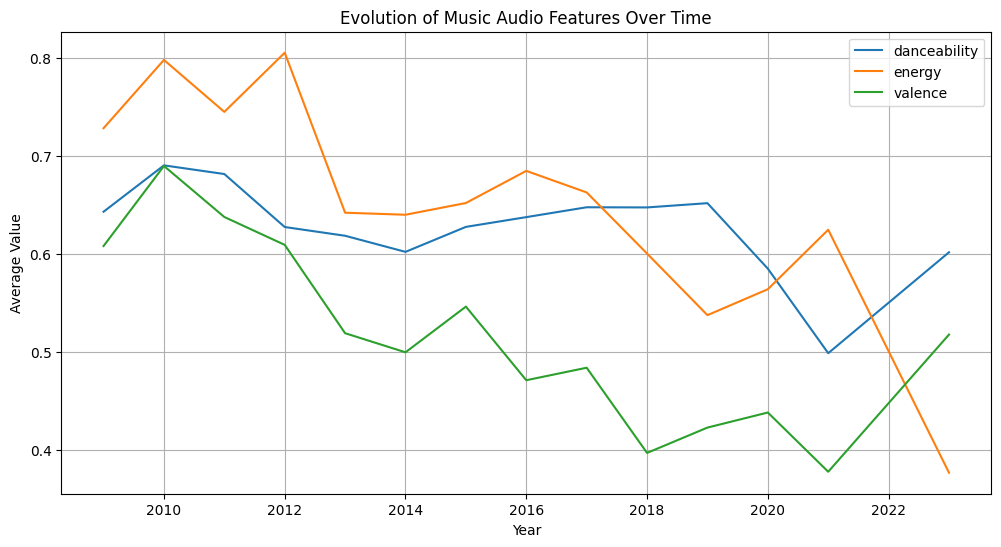

In [15]:
plt.figure(figsize=(12,6))
for feature in ["danceability", "energy", "valence"]:
    plt.plot(
        yearly_trends["year"],
        yearly_trends[feature],
        label=feature
    )

plt.title("Evolution of Music Audio Features Over Time")
plt.xlabel("Year")
plt.ylabel("Average Value")
plt.legend()
plt.grid(True)
plt.show()


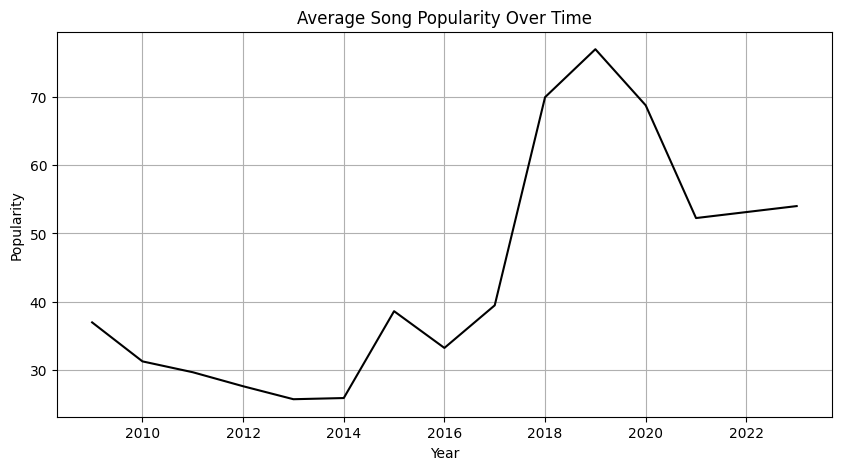

In [16]:
plt.figure(figsize=(10,5))
plt.plot(
    yearly_trends["year"],
    yearly_trends["popularity"],
    color="black"
)
plt.title("Average Song Popularity Over Time")
plt.xlabel("Year")
plt.ylabel("Popularity")
plt.grid(True)
plt.show()


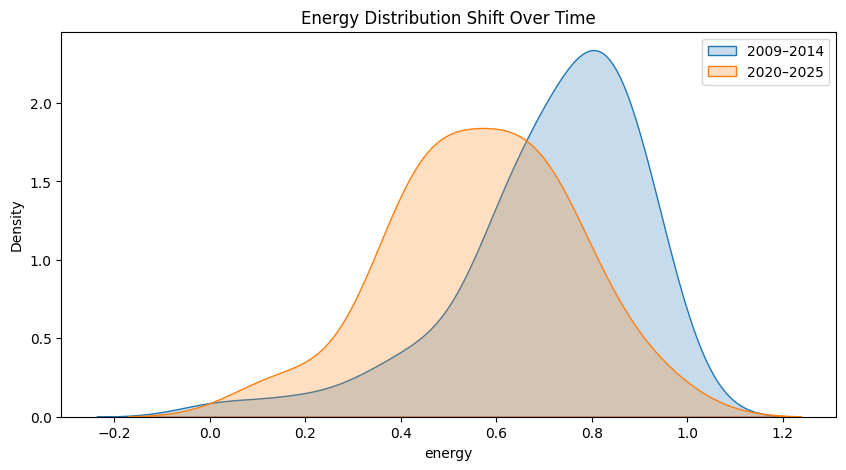

In [17]:
early = analysis_df[analysis_df["year"] <= 2014]
recent = analysis_df[analysis_df["year"] >= 2020]

plt.figure(figsize=(10,5))
sns.kdeplot(early["energy"], label="2009–2014", fill=True)
sns.kdeplot(recent["energy"], label="2020–2025", fill=True)
plt.title("Energy Distribution Shift Over Time")
plt.legend()
plt.show()
